<a href="https://colab.research.google.com/github/prasuna-63y/Electric-Motor-Temperature-Prediction/blob/main/Rotor_Temperature_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('pmsm_temperature_data.csv.csv')
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17.0
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17.0
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17.0
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17.0
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17.0


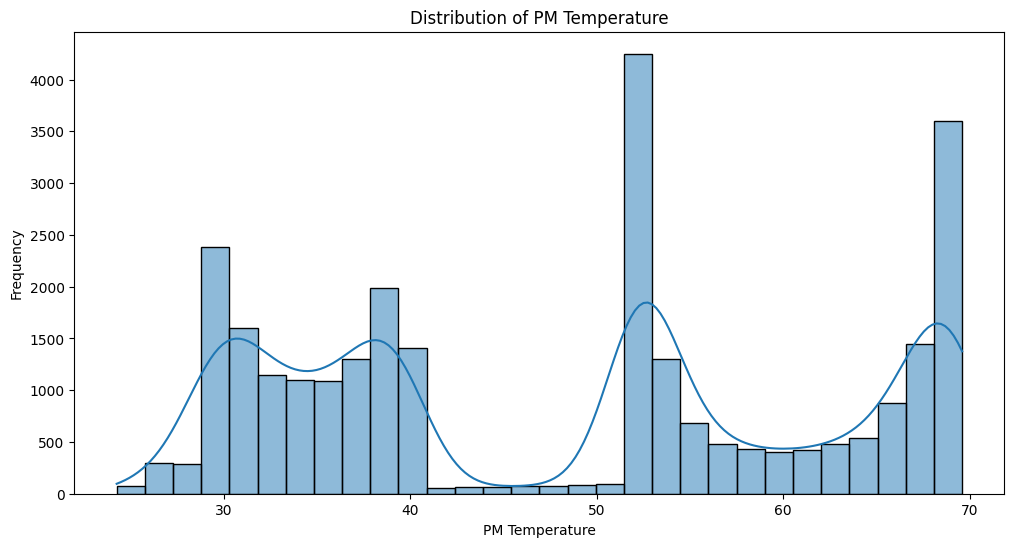

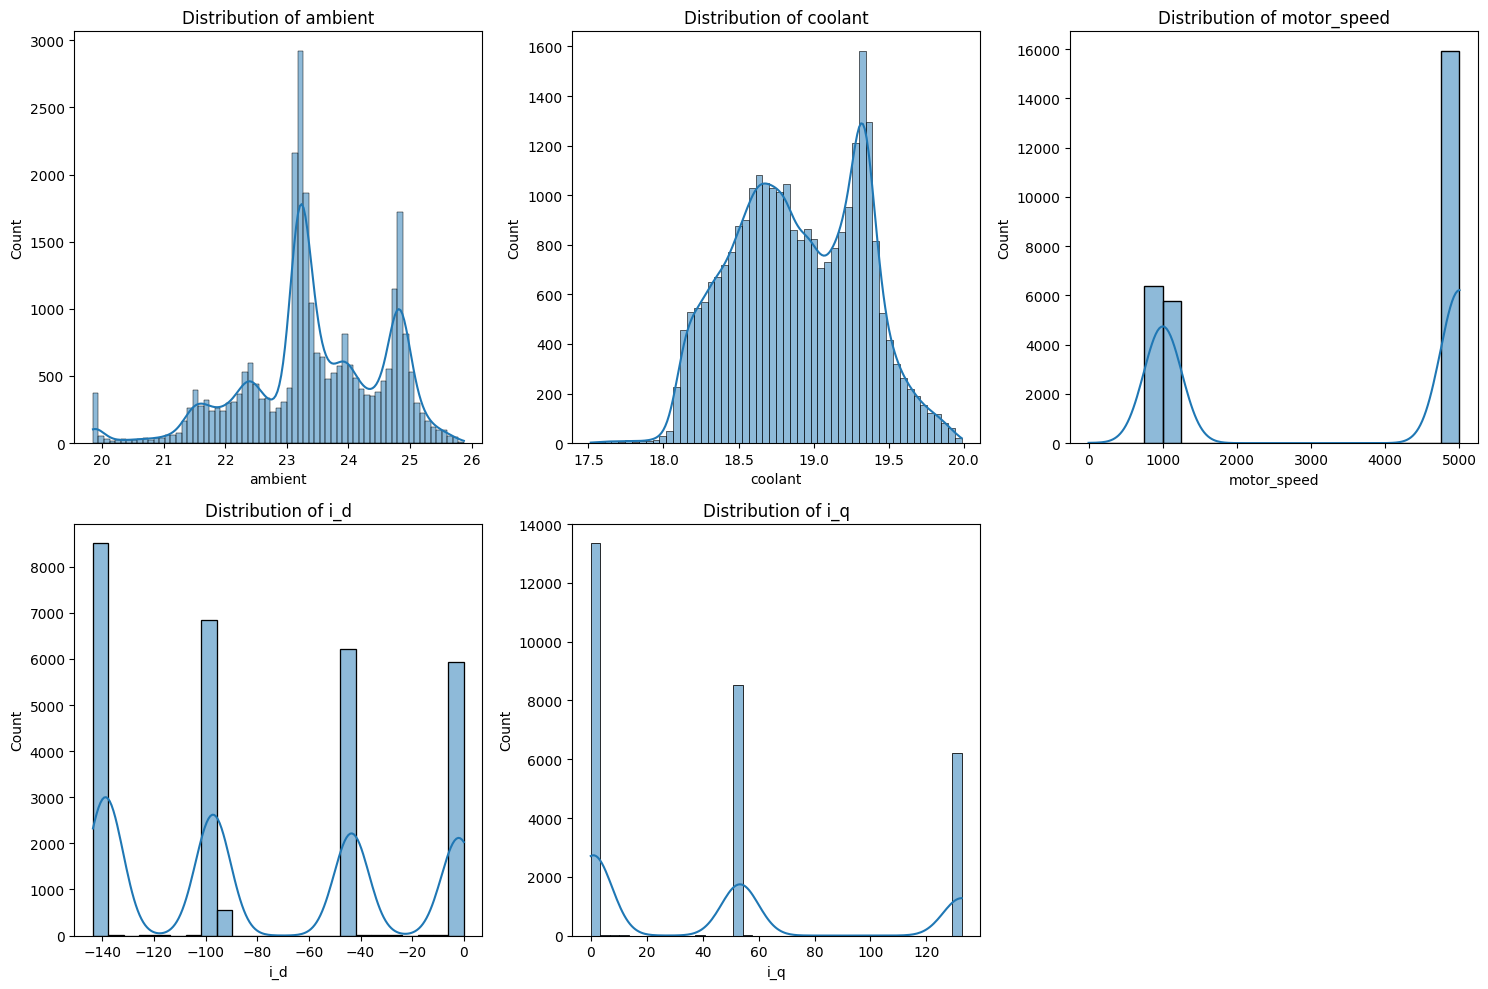

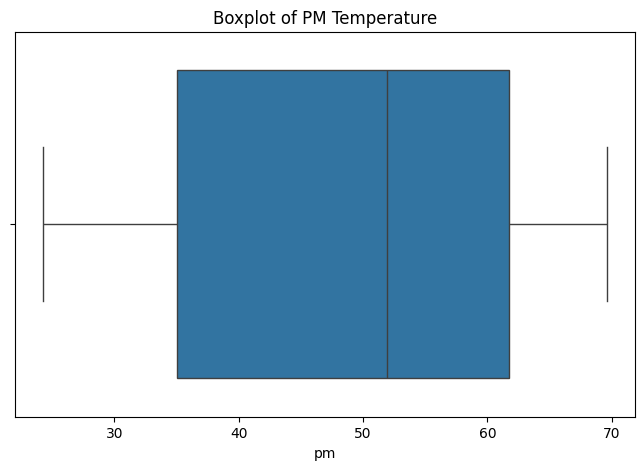

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.histplot(df['pm'], kde=True, bins=30)
plt.title("Distribution of PM Temperature")
plt.xlabel("PM Temperature")
plt.ylabel("Frequency")
plt.show()

features = ['ambient', 'coolant', 'motor_speed', 'i_d', 'i_q']

plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['pm'])
plt.title("Boxplot of PM Temperature")
plt.show()




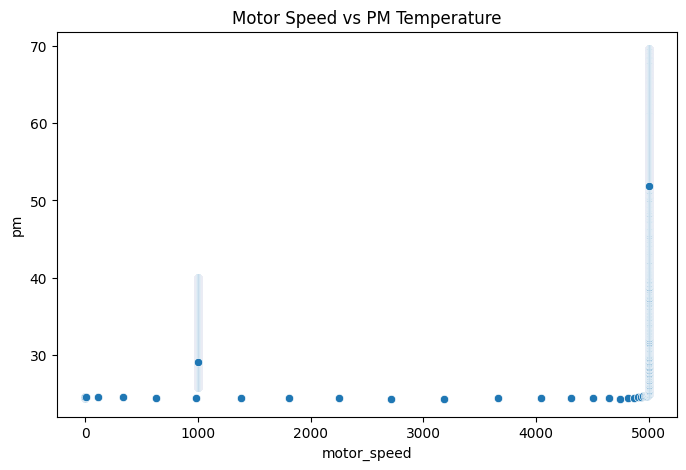

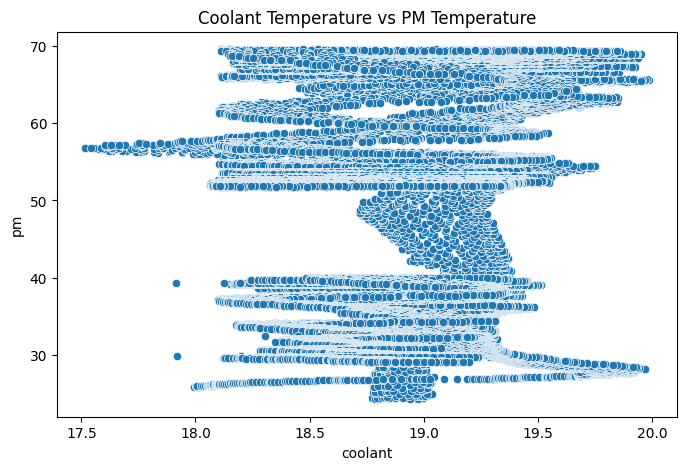

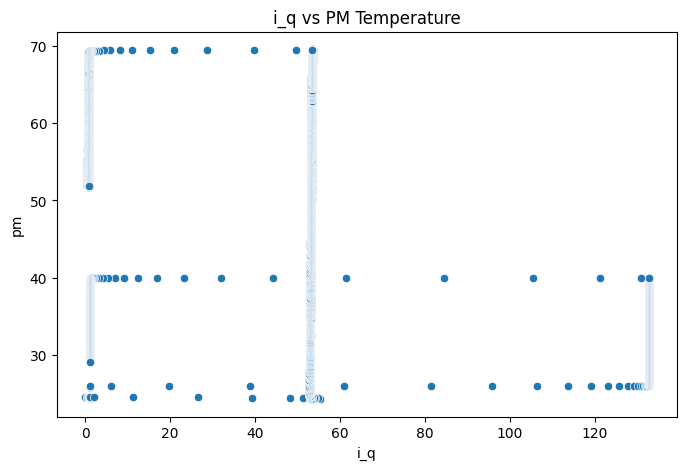

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['motor_speed'], y=df['pm'])
plt.title("Motor Speed vs PM Temperature")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['coolant'], y=df['pm'])
plt.title("Coolant Temperature vs PM Temperature")
plt.show()
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['i_q'], y=df['pm'])
plt.title("i_q vs PM Temperature")
plt.show()


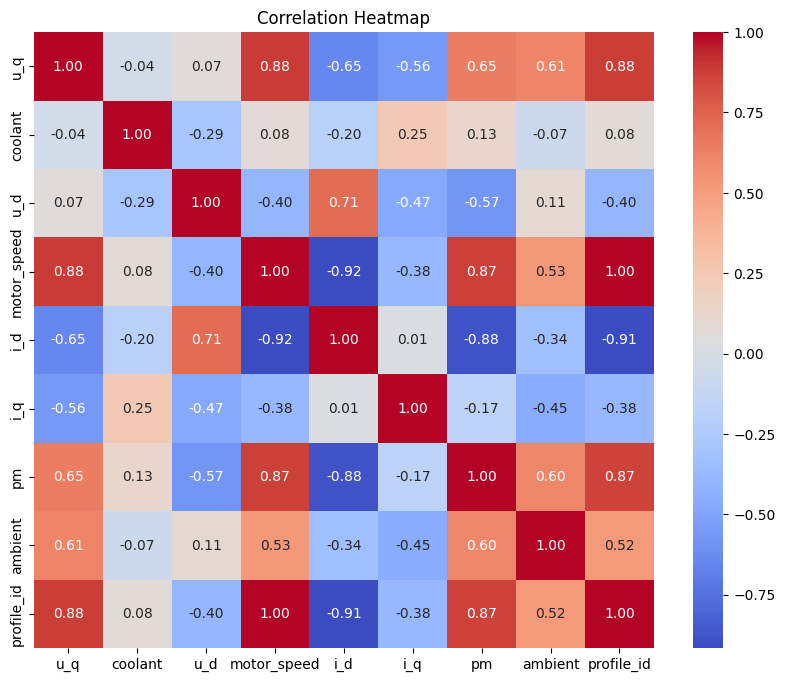

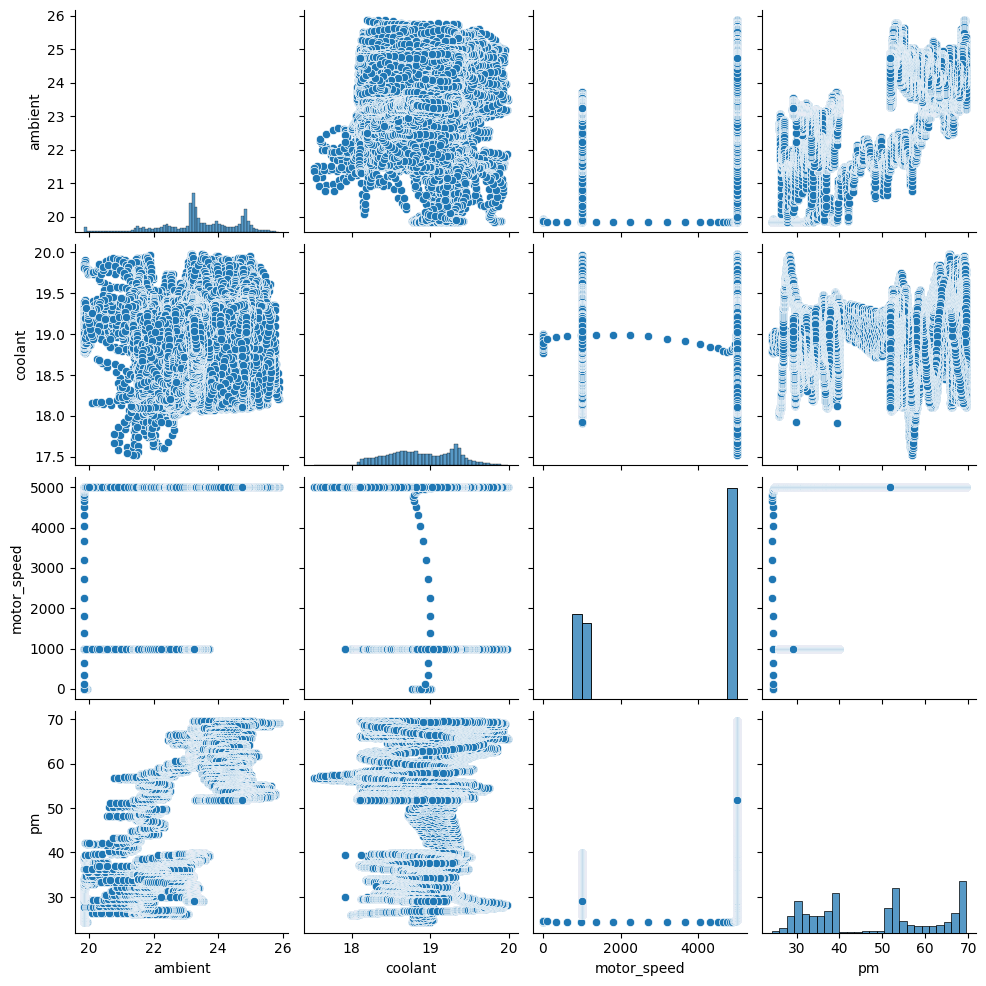

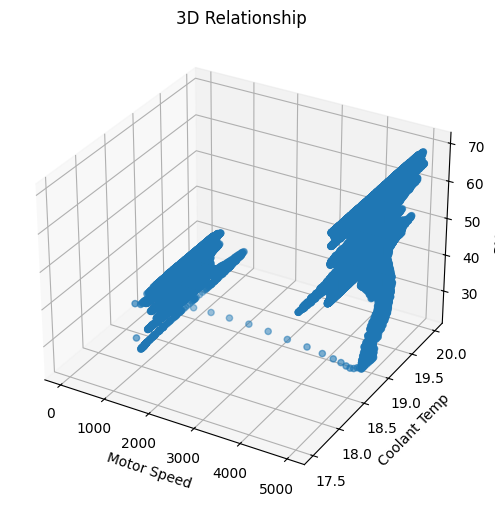

In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
sns.pairplot(df[['ambient','coolant','motor_speed','pm']])
plt.show()
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['motor_speed'], df['coolant'], df['pm'])
ax.set_xlabel("Motor Speed")
ax.set_ylabel("Coolant Temp")
ax.set_zlabel("PM Temp")

plt.title("3D Relationship")
plt.show()


In [ ]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
Index: 28114 entries, 0 to 28113
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   u_q          28114 non-null  float64
 1   coolant      28114 non-null  float64
 2   u_d          28114 non-null  float64
 3   motor_speed  28114 non-null  float64
 4   i_d          28114 non-null  float64
 5   i_q          28114 non-null  float64
 6   pm           28114 non-null  float64
 7   ambient      28114 non-null  float64
 8   profile_id   28114 non-null  float64
dtypes: float64(9)
memory usage: 2.1 MB


,u_q,coolant,u_d,motor_speed,i_d,i_q,pm,ambient,profile_id
count,28114.000000,28114.000000,28114.000000,28114.000000,28114.000000,28114.000000,28114.000000,28114.000000,28114.000000
mean,81.190443,18.896062,-40.321073,3265.553872,-77.710878,45.991534,48.281217,23.440903,11.813972
std,34.518994,0.426594,39.760383,1983.231479,51.983459,51.389945,14.200675,1.137857,5.944637
min,-0.974433,17.516184,-97.081703,-0.004142,-143.617004,-0.000785,24.264736,19.850620,5.000000
25%,49.389601,18.565468,-95.259256,999.991638,-138.160683,0.986889,35.070344,22.979434,5.000000
50%,87.026695,18.881069,-42.840477,4999.944824,-96.771873,53.120522,51.932928,23.335036,17.000000
75%,130.226151,19.270280,-6.150009,4999.949219,-43.510624,53.463409,61.754469,24.359284,17.000000
max,131.331100,19.986029,0.851181,4999.971191,0.004419,132.619171,69.588531,25.875355,17.000000


In [ ]:
df.head()


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17.0
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17.0
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17.0
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17.0
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17.0


In [ ]:
df = df.drop(['stator_yoke', 'stator_tooth', 'stator_winding', 'torque'], axis=1)


In [ ]:
df.head()


,u_q,coolant,u_d,motor_speed,i_d,i_q,pm,ambient,profile_id
0,-0.450682,18.805172,-0.350055,0.002866,0.004419,0.000328,24.554214,19.850691,17.0
1,-0.325737,18.818571,-0.305803,0.000257,0.000606,-0.000785,24.538078,19.850672,17.0
2,-0.440864,18.828770,-0.372503,0.002355,0.001290,0.000386,24.544693,19.850657,17.0
3,-0.327026,18.835567,-0.316199,0.006105,0.000026,0.002046,24.554018,19.850647,17.0
4,-0.471150,18.857033,-0.332272,0.003133,-0.064317,0.037184,24.565397,19.850639,17.0


In [ ]:
df.isnull().sum()


,0
u_q,0
coolant,0
u_d,0
motor_speed,1
i_d,1
i_q,1
pm,1
ambient,1
profile_id,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib
df.dropna(inplace=True)
X = df[['ambient','coolant','u_d','u_q','motor_speed','i_d','i_q']]
y = df['pm']
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, 'transform.save')

['transform.save']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=3
)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
lr = LinearRegression()
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=3
)
rf = RandomForestRegressor(n_estimators=100, random_state=3)

# Train models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=3)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression Prediction
lr_pred = lr.predict(X_test)

print("Linear Regression Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))
print("-----------------------------------")

# Decision Tree Prediction
dt_pred = dt.predict(X_test)

print("Decision Tree Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score:", r2_score(y_test, dt_pred))
print("-----------------------------------")

# Random Forest Prediction
rf_pred = rf.predict(X_test)

print("Random Forest Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))


Linear Regression Performance
RMSE: 2.3102653353738165
R2 Score: 0.9735042112709816
-----------------------------------
Decision Tree Performance
RMSE: 0.9281949014686469
R2 Score: 0.9957230764655114
-----------------------------------
Random Forest Performance
RMSE: 0.5759463647071001
R2 Score: 0.998353289663854


In [ ]:
joblib.dump(dt, "model.save")



['model.save']